# Edge-BPE release benchmark

This notebook is the BPE-specific companion to `coarsener_scaling_sweep.ipynb`.
It uses the **same near-binary and near-star tree families**, while adding the
checks that matter specifically for Edge BPE:

- Python versus warmed Numba fitting performance;
- all three built-in scoring policies;
- exact Python/Numba rule-history parity;
- identical encoded output from both fitting backends;
- exact full decoding and caller-input nonmutation;
- rule count, raw matching-edge count, actual contraction count, and compression.

The backend setting changes BPE **fitting only**. Transformation and decoding
use the same fitted encoder/decoder implementation, so backend differences in
those phases should be treated as timing noise rather than backend speedups.
Graph generation and correctness signatures are outside timed regions.

## 0. Imports and repository checkout

Run this notebook from anywhere inside the repository. Results record the
Python environment and Git commit when available.

In [1]:
from __future__ import annotations

import gc
import json
import os
import random
import sys
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
from IPython.display import display


def find_project_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in (current, *current.parents):
        if (candidate / "pyproject.toml").is_file() and (candidate / "tree_coarsening").is_dir():
            return candidate
    raise RuntimeError("Could not locate the tree-coarsening repository root.")


ROOT = find_project_root(Path.cwd())
BENCHMARK_DIR = ROOT / "benchmarks"
for entry in (str(ROOT), str(BENCHMARK_DIR)):
    if entry not in sys.path:
        sys.path.insert(0, entry)

from benchmark_common import (  # noqa: E402
    environment_metadata,
    make_benchmark_tree,
    numba_is_available,
    raw_signature,
)
from tree_coarsening import EdgeBPECoarsener  # noqa: E402

ENVIRONMENT = environment_metadata(ROOT)
ENVIRONMENT

{'python': '3.13.13',
 'python_implementation': 'CPython',
 'python_executable': '<PYTHON_EXECUTABLE>',
 'platform': 'Linux-6.17.0-1025-oem-x86_64-with-glibc2.39',
 'processor': 'x86_64',
 'logical_cpu_count': 24,
 'networkx': '3.6.1',
 'tree_coarsening': '0.11.0',
 'git_commit': 'unknown',
 'numpy': '2.4.6',
 'numba': '0.65.1',
 'physical_memory_bytes': 134489358336}

## 1. Controls

`standard` is the recommended visual pre-release run. `smoke` verifies the
notebook quickly, and `extended` adds larger trees on a quiet machine. The
measured rows use full validation because that is the public default path.

In [2]:
PROFILES = {
    "smoke": {"sizes": (127, 255, 511), "repeats": 1},
    "standard": {"sizes": (500, 1_000, 2_000, 4_000, 8_000, 16_000), "repeats": 3},
    "extended": {
        "sizes": (1_000, 2_000, 4_000, 8_000, 16_000, 32_000, 64_000),
        "repeats": 3,
    },
}

PROFILE = os.environ.get("TREE_COARSENING_BENCH_PROFILE", "standard")
if PROFILE not in PROFILES:
    raise ValueError(f"Unknown benchmark profile {PROFILE!r}; choose from {tuple(PROFILES)}")

SIZES = PROFILES[PROFILE]["sizes"]
REPEATS = PROFILES[PROFILE]["repeats"]
SHAPES = ("near_binary", "near_star")
PAIR_SCORES = ("count", "normalized", "size_weighted")
BACKENDS = ["python"]
if numba_is_available():
    BACKENDS.append("numba")

VALIDATE = "full"
NUM_MERGES = 12
MIN_PAIR_COUNT = 2
SAVE_RESULTS = True
TASK_ORDER_SEED = 20260621

{
    "profile": PROFILE,
    "sizes": SIZES,
    "repeats": REPEATS,
    "shapes": SHAPES,
    "pair_scores": PAIR_SCORES,
    "backends": BACKENDS,
    "validate": VALIDATE,
    "num_merges": NUM_MERGES,
    "min_pair_count": MIN_PAIR_COUNT,
}

{'profile': 'extended',
 'sizes': (1000, 2000, 4000, 8000, 16000, 32000, 64000),
 'repeats': 3,
 'shapes': ('near_binary', 'near_star'),
 'pair_scores': ('count', 'normalized', 'size_weighted'),
 'backends': ['python', 'numba'],
 'validate': 'full',
 'num_merges': 12,
 'min_pair_count': 2}

## 2. Build controlled trees

Only the node count changes within each shape. Tree count and total vertices are
not changed together, so the x-axis has one interpretation. The same raw graph
object is supplied to every scorer and backend; nonmutation is checked later.

In [3]:
corpora = {}
raw_signatures = {}
generation_rows = []

for shape in SHAPES:
    for n_nodes in SIZES:
        started = perf_counter()
        graph = make_benchmark_tree(shape, n_nodes, seed=TASK_ORDER_SEED + n_nodes)
        generation_seconds = perf_counter() - started
        key = (shape, n_nodes)
        corpora[key] = graph
        raw_signatures[key] = raw_signature(graph)
        generation_rows.append(
            {
                "shape": shape,
                "n_nodes": graph.number_of_nodes(),
                "n_edges": graph.number_of_edges(),
                "generation_seconds": generation_seconds,
                "maximum_out_degree": max(dict(graph.out_degree()).values()),
            }
        )

generation_df = pd.DataFrame(generation_rows)
generation_df

,shape,n_nodes,n_edges,generation_seconds,maximum_out_degree
0,near_binary,1000,999,0.002741,2
1,near_binary,2000,1999,0.002487,2
2,near_binary,4000,3999,0.005244,2
3,near_binary,8000,7999,0.009786,2
4,near_binary,16000,15999,0.020670,2
5,near_binary,32000,31999,0.041652,2
6,near_binary,64000,63999,0.183311,2
7,near_star,1000,999,0.001647,250
8,near_star,2000,1999,0.003022,500
9,near_star,4000,3999,0.003825,1000


## 3. Warm-up outside measured rows

The first Numba fit in a kernel often includes compilation. It is recorded
separately, then every scorer is exercised before measured rows. This is a
**first fit in the current kernel**, not a guaranteed clean-process cold-start
measurement; use a fresh Python process for release-grade cold-start numbers.

In [4]:
warmup_graph = make_benchmark_tree("near_binary", 127, seed=0)
warmup_expected = raw_signature(warmup_graph)
warmup_rows = []

for backend in BACKENDS:
    for score_index, pair_score in enumerate(PAIR_SCORES):
        model = EdgeBPECoarsener(
            num_merges=2,
            min_pair_count=1,
            pair_score=pair_score,
            backend=backend,
            model_id=f"bpe-warmup-{backend}-{pair_score}",
        )
        started = perf_counter()
        model.fit([warmup_graph], validate=False)
        fit_seconds = perf_counter() - started
        encoded = model.transform(warmup_graph, validate=False)
        decoded = model.decode(encoded, validate=False)
        if raw_signature(decoded) != warmup_expected:
            raise AssertionError(f"Warm-up round trip failed for {backend}/{pair_score}.")
        warmup_rows.append(
            {
                "backend": backend,
                "pair_score": pair_score,
                "fit_seconds": fit_seconds,
                "first_numba_fit_in_kernel": backend == "numba" and score_index == 0,
            }
        )
        del model, encoded, decoded
        gc.collect()

warmup_df = pd.DataFrame(warmup_rows)
warmup_df

,backend,pair_score,fit_seconds,first_numba_fit_in_kernel
0,python,count,0.001286,False
1,python,normalized,0.000764,False
2,python,size_weighted,0.000717,False
3,numba,count,1.663911,True
4,numba,normalized,0.000856,False
5,numba,size_weighted,0.000935,False


## 4. Timed sweep with semantic parity checks

Each repetition constructs fresh Python and Numba fitters. Cases are shuffled
deterministically, and backend fit order alternates within a case. Because the
backend setting affects fitting only, `transform` and `decode` are timed **once**
per case with the Python-fitted artifact and their timings are shared by both
backend rows. This avoids presenting duplicate transform/decode noise as a
backend effect.

Rule history is compared on every repetition. Encoded output parity is checked by exact NetworkX object equality once per
shape/size/scorer combination (`repeat == 0`). Model construction,
graph generation, garbage collection, signatures, and parity comparisons are
outside timed regions.

In [5]:
tasks = [
    (repeat, shape, n_nodes, pair_score)
    for repeat in range(REPEATS)
    for shape in SHAPES
    for n_nodes in SIZES
    for pair_score in PAIR_SCORES
]
random.Random(TASK_ORDER_SEED).shuffle(tasks)

rows = []
for task_index, (repeat, shape, n_nodes, pair_score) in enumerate(tasks, start=1):
    graph = corpora[(shape, n_nodes)]
    expected_raw = raw_signatures[(shape, n_nodes)]
    model_id = f"bpe-bench-{shape}-{n_nodes}-{pair_score}-{repeat}"

    backend_order = list(BACKENDS)
    random.Random(TASK_ORDER_SEED + task_index).shuffle(backend_order)
    models = {}
    fit_seconds_by_backend = {}

    for backend in backend_order:
        model = EdgeBPECoarsener(
            num_merges=NUM_MERGES,
            min_pair_count=MIN_PAIR_COUNT,
            pair_score=pair_score,
            backend=backend,
            model_id=model_id,
        )
        gc.collect()
        started = perf_counter()
        model.fit([graph], validate=VALIDATE)
        fit_seconds_by_backend[backend] = perf_counter() - started
        models[backend] = model

    history_parity_ok = None
    rule_parity_ok = None
    if "numba" in models:
        history_parity_ok = models["python"].history_ == models["numba"].history_
        rule_parity_ok = models["python"].encoder_.rules == models["numba"].encoder_.rules
        if not (history_parity_ok and rule_parity_ok):
            raise AssertionError(
                f"Python/Numba rule parity failure for shape={shape}, n={n_nodes}, "
                f"score={pair_score}, repeat={repeat}."
            )

    canonical_model = models["python"]
    started = perf_counter()
    encoded = canonical_model.transform(graph, validate=VALIDATE)
    transform_seconds = perf_counter() - started

    started = perf_counter()
    decoded = canonical_model.decode(encoded, validate=VALIDATE)
    decode_seconds = perf_counter() - started

    roundtrip_ok = raw_signature(decoded) == expected_raw
    input_unchanged = raw_signature(graph) == expected_raw
    if not roundtrip_ok or not input_unchanged:
        raise AssertionError(
            f"Correctness failure for shape={shape}, n={n_nodes}, "
            f"score={pair_score}, repeat={repeat}: "
            f"roundtrip={roundtrip_ok}, unchanged={input_unchanged}"
        )

    encoded_parity_ok = None
    if "numba" in models and repeat == 0:
        parity_encoded = models["numba"].transform(graph, validate=VALIDATE)
        encoded_parity_ok = nx.utils.graphs_equal(encoded, parity_encoded)
        if not encoded_parity_ok:
            raise AssertionError(
                f"Python/Numba encoded-output parity failure for shape={shape}, "
                f"n={n_nodes}, score={pair_score}."
            )
        del parity_encoded

    for backend in BACKENDS:
        model = models[backend]
        fit_seconds = fit_seconds_by_backend[backend]
        rows.append(
            {
                "repeat": repeat,
                "shape": shape,
                "n_nodes": n_nodes,
                "pair_score": pair_score,
                "backend_requested": backend,
                "backend_used": model.backend_used_,
                "fit_seconds": fit_seconds,
                "transform_seconds": transform_seconds,
                "decode_seconds": decode_seconds,
                "total_seconds": fit_seconds + transform_seconds + decode_seconds,
                "shared_phase_backend": "python",
                "rule_count": len(canonical_model.history_),
                "raw_pair_count_sum": sum(
                    int(event["count"]) for event in canonical_model.history_
                ),
                "actual_event_count_sum": sum(
                    int(event["actual_events"]) for event in canonical_model.history_
                ),
                "encoded_nodes": encoded.number_of_nodes(),
                "compression_ratio": encoded.number_of_nodes() / n_nodes,
                "roundtrip_ok": roundtrip_ok,
                "input_unchanged": input_unchanged,
                "history_parity_ok": history_parity_ok,
                "rule_parity_ok": rule_parity_ok,
                "encoded_parity_ok": encoded_parity_ok,
            }
        )

    if task_index % max(1, len(tasks) // 10) == 0:
        print(f"completed {task_index}/{len(tasks)} cases")

    del models, fit_seconds_by_backend, encoded, decoded
    gc.collect()

results_df = pd.DataFrame(rows).sort_values(
    ["shape", "pair_score", "backend_requested", "n_nodes", "repeat"]
)
results_df.head()

completed 12/126 cases
completed 24/126 cases
completed 36/126 cases
completed 48/126 cases
completed 60/126 cases
completed 72/126 cases
completed 84/126 cases
completed 96/126 cases
completed 108/126 cases
completed 120/126 cases


,repeat,shape,n_nodes,pair_score,backend_requested,backend_used,fit_seconds,transform_seconds,decode_seconds,total_seconds,...,rule_count,raw_pair_count_sum,actual_event_count_sum,encoded_nodes,compression_ratio,roundtrip_ok,input_unchanged,history_parity_ok,rule_parity_ok,encoded_parity_ok
177,0,near_binary,1000,count,numba,numba,0.005744,0.011395,0.025819,0.042959,...,12,1029,772,228,0.228,True,True,True,True,True
239,1,near_binary,1000,count,numba,numba,0.005816,0.011597,0.026220,0.043633,...,12,1029,772,228,0.228,True,True,True,True,None
131,2,near_binary,1000,count,numba,numba,0.005669,0.011359,0.025910,0.042938,...,12,1029,772,228,0.228,True,True,True,True,None
5,0,near_binary,2000,count,numba,numba,0.009850,0.021960,0.047921,0.079731,...,12,2044,1564,436,0.218,True,True,True,True,True
55,1,near_binary,2000,count,numba,numba,0.010570,0.023403,0.051251,0.085224,...,12,2044,1564,436,0.218,True,True,True,True,None


## 5. Aggregate and verify

The median is the primary timing estimate. Minimum and maximum values remain in
the summary so unstable points are visible. Rule and work counts should match
exactly across backends; score policies may legitimately differ from one another.

In [6]:
if not results_df["roundtrip_ok"].all() or not results_df["input_unchanged"].all():
    raise AssertionError("At least one benchmark row failed correctness checks.")

for column in ("history_parity_ok", "rule_parity_ok", "encoded_parity_ok"):
    applicable = results_df[column].dropna()
    if not applicable.empty and not applicable.astype(bool).all():
        raise AssertionError(f"At least one row failed {column}.")

summary_df = (
    results_df.groupby(
        ["shape", "n_nodes", "pair_score", "backend_requested"],
        as_index=False,
    )
    .agg(
        fit_median=("fit_seconds", "median"),
        fit_min=("fit_seconds", "min"),
        fit_max=("fit_seconds", "max"),
        transform_median=("transform_seconds", "median"),
        decode_median=("decode_seconds", "median"),
        total_median=("total_seconds", "median"),
        total_min=("total_seconds", "min"),
        total_max=("total_seconds", "max"),
        rule_count=("rule_count", "median"),
        raw_pair_count_sum=("raw_pair_count_sum", "median"),
        actual_event_count_sum=("actual_event_count_sum", "median"),
        encoded_nodes=("encoded_nodes", "median"),
        compression_ratio=("compression_ratio", "median"),
    )
    .sort_values(["shape", "pair_score", "backend_requested", "n_nodes"])
)
summary_df["nodes_per_fit_second"] = summary_df["n_nodes"] / summary_df["fit_median"]
summary_df

,shape,n_nodes,pair_score,backend_requested,fit_median,fit_min,fit_max,transform_median,decode_median,total_median,total_min,total_max,rule_count,raw_pair_count_sum,actual_event_count_sum,encoded_nodes,compression_ratio,nodes_per_fit_second
0,near_binary,1000,count,numba,0.005744,0.005669,0.005816,0.011395,0.025910,0.042959,0.042938,0.043633,12.0,1029.0,772.0,228.0,0.228000,174096.525726
6,near_binary,2000,count,numba,0.010345,0.009850,0.010570,0.023311,0.050328,0.083984,0.079731,0.085224,12.0,2044.0,1564.0,436.0,0.218000,193334.167340
12,near_binary,4000,count,numba,0.019912,0.019577,0.020751,0.047682,0.101266,0.168832,0.168373,0.169711,12.0,4440.0,2830.0,1170.0,0.292500,200887.057396
18,near_binary,8000,count,numba,0.040071,0.039882,0.040806,0.096598,0.213513,0.349993,0.344827,0.359466,12.0,8309.0,6323.0,1677.0,0.209625,199645.609309
24,near_binary,16000,count,numba,0.089114,0.087066,0.089878,0.209090,0.645391,0.943596,0.928690,0.948981,12.0,16069.0,11966.0,4034.0,0.252125,179544.515834
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,near_star,4000,size_weighted,python,0.024860,0.024103,0.024911,0.046967,0.082379,0.154060,0.153510,0.154997,12.0,11955.0,2010.0,1990.0,0.497500,160901.344200
65,near_star,8000,size_weighted,python,0.049654,0.049616,0.049931,0.093573,0.166631,0.309905,0.305246,0.310758,12.0,23955.0,4010.0,3990.0,0.498750,161113.364320
71,near_star,16000,size_weighted,python,0.100732,0.100532,0.104631,0.187383,0.539969,0.829716,0.818588,0.847462,12.0,47955.0,8010.0,7990.0,0.499375,158837.832827
77,near_star,32000,size_weighted,python,0.213995,0.203285,0.217035,0.590097,0.906594,1.710686,1.623310,1.816088,12.0,95955.0,16010.0,15990.0,0.499688,149536.520648


## 6. Fit-time scaling

These are the backend-sensitive curves. Compare Python and Numba only after the
warm-up cell has completed, and investigate sustained changes rather than one
isolated point.

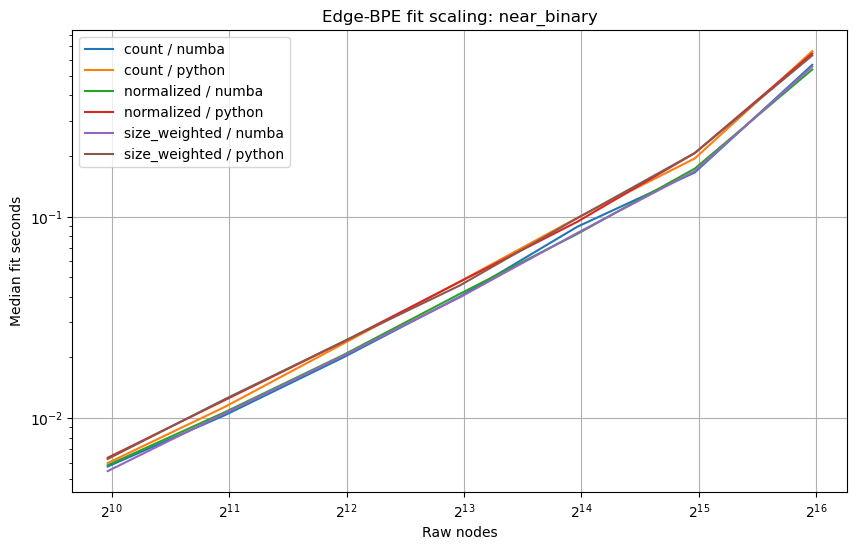

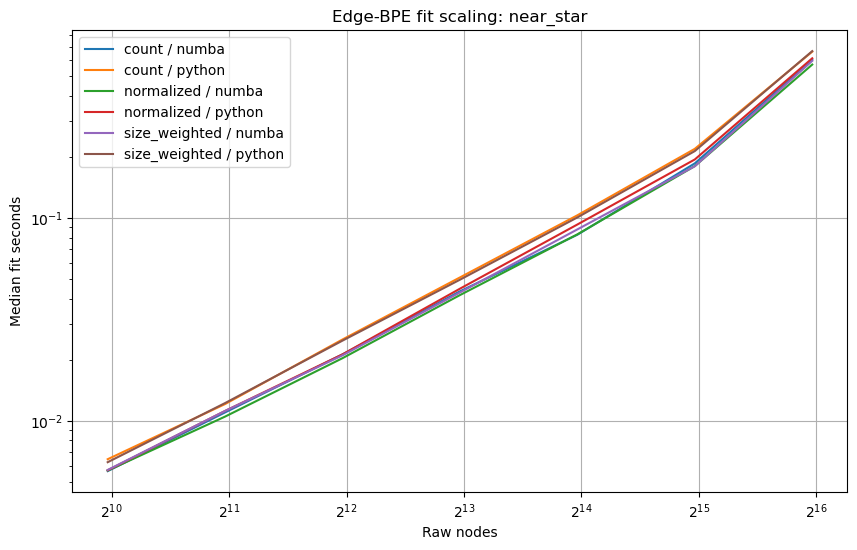

In [7]:
for shape in SHAPES:
    figure = plt.figure(figsize=(10, 6))
    axis = figure.gca()
    subset = summary_df[summary_df["shape"] == shape]
    for (pair_score, backend), group in subset.groupby(
        ["pair_score", "backend_requested"], sort=False
    ):
        group = group.sort_values("n_nodes")
        axis.plot(
            group["n_nodes"],
            group["fit_median"],
            label=f"{pair_score} / {backend}",
        )
    axis.set_xscale("log", base=2)
    axis.set_yscale("log")
    axis.set_xlabel("Raw nodes")
    axis.set_ylabel("Median fit seconds")
    axis.set_title(f"Edge-BPE fit scaling: {shape}")
    axis.grid(True)
    axis.legend()
    plt.show()

## 7. End-to-end public-call time

This is `fit + transform + full decode`. The transform/decode timing is measured
once per case and reused for both backend rows, so the difference between the
backend curves is exactly their fit-time difference rather than duplicate phase
noise.

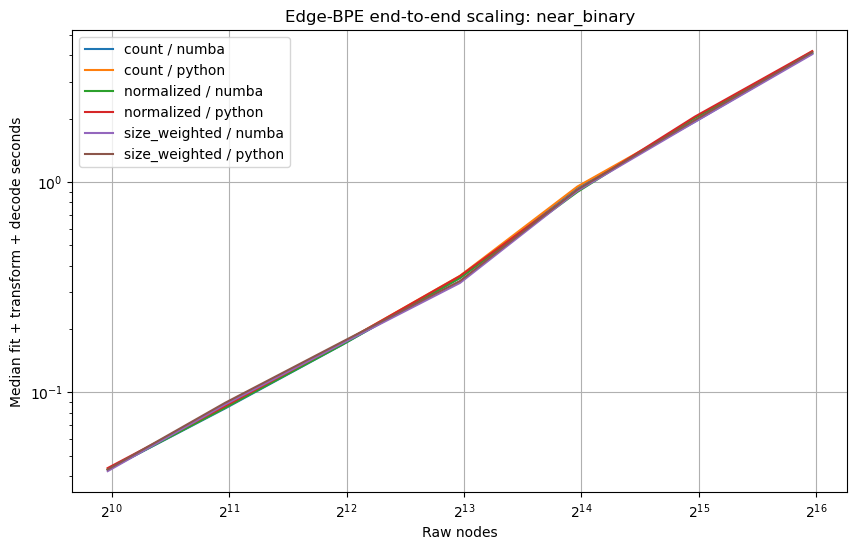

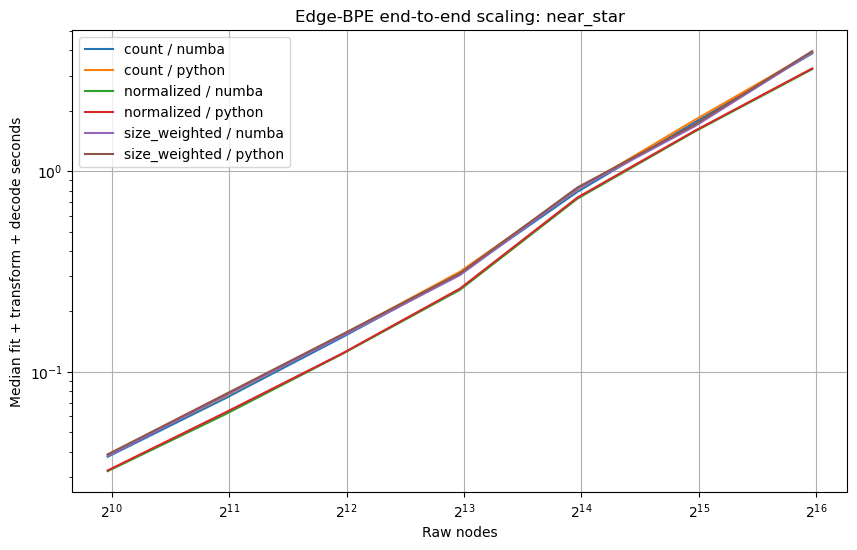

In [8]:
for shape in SHAPES:
    figure = plt.figure(figsize=(10, 6))
    axis = figure.gca()
    subset = summary_df[summary_df["shape"] == shape]
    for (pair_score, backend), group in subset.groupby(
        ["pair_score", "backend_requested"], sort=False
    ):
        group = group.sort_values("n_nodes")
        axis.plot(
            group["n_nodes"],
            group["total_median"],
            label=f"{pair_score} / {backend}",
        )
    axis.set_xscale("log", base=2)
    axis.set_yscale("log")
    axis.set_xlabel("Raw nodes")
    axis.set_ylabel("Median fit + transform + decode seconds")
    axis.set_title(f"Edge-BPE end-to-end scaling: {shape}")
    axis.grid(True)
    axis.legend()
    plt.show()

## 8. Warm Numba fit speedup

A ratio above one means the warmed Numba fit was faster. This ratio excludes the
first-fit compilation value shown in the warm-up table.

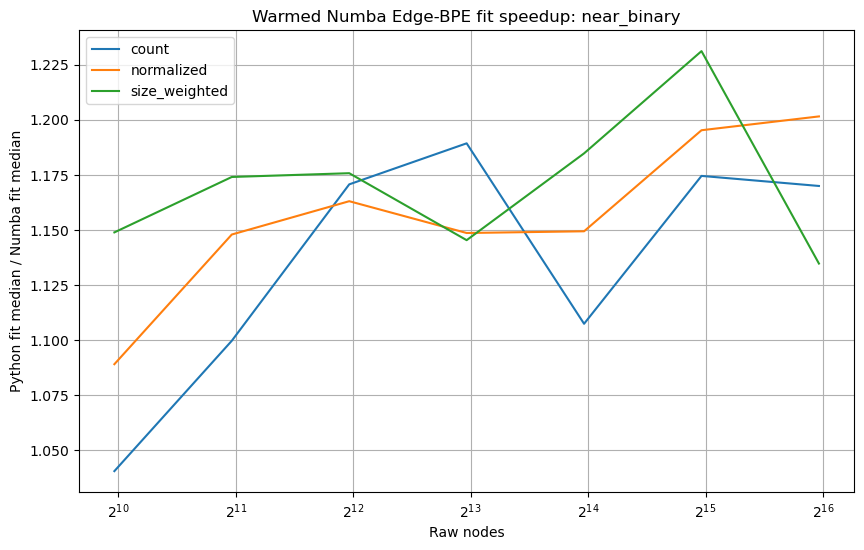

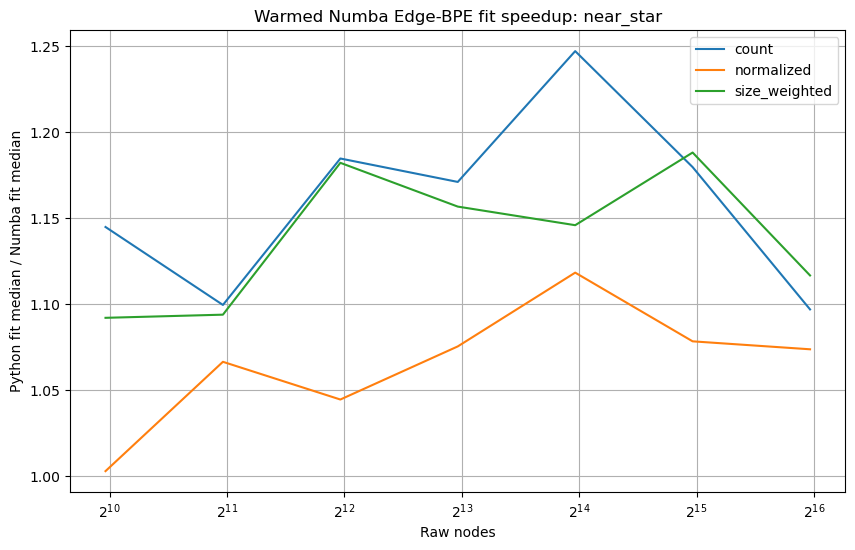

,shape,n_nodes,pair_score,python_fit_median,numba_fit_median,numba_fit_speedup
0,near_binary,1000,count,0.005977,0.005744,1.040581
1,near_binary,2000,count,0.011376,0.010345,1.099722
2,near_binary,4000,count,0.023310,0.019912,1.170679
3,near_binary,8000,count,0.047656,0.040071,1.189293
4,near_binary,16000,count,0.098688,0.089114,1.107432
5,near_binary,32000,count,0.194561,0.165653,1.174510
6,near_binary,64000,count,0.663225,0.566884,1.169949
7,near_binary,1000,normalized,0.006349,0.005830,1.089092
8,near_binary,2000,normalized,0.012295,0.010711,1.147922
9,near_binary,4000,normalized,0.023805,0.020468,1.163036


In [9]:
python_fit = summary_df[summary_df["backend_requested"] == "python"][
    ["shape", "n_nodes", "pair_score", "fit_median"]
].rename(columns={"fit_median": "python_fit_median"})
numba_fit = summary_df[summary_df["backend_requested"] == "numba"][
    ["shape", "n_nodes", "pair_score", "fit_median"]
].rename(columns={"fit_median": "numba_fit_median"})

speedup_df = python_fit.merge(
    numba_fit,
    on=["shape", "n_nodes", "pair_score"],
    how="inner",
)
if not speedup_df.empty:
    speedup_df["numba_fit_speedup"] = (
        speedup_df["python_fit_median"] / speedup_df["numba_fit_median"]
    )
    for shape in SHAPES:
        figure = plt.figure(figsize=(10, 6))
        axis = figure.gca()
        subset = speedup_df[speedup_df["shape"] == shape]
        for pair_score, group in subset.groupby("pair_score", sort=False):
            group = group.sort_values("n_nodes")
            axis.plot(
                group["n_nodes"],
                group["numba_fit_speedup"],
                label=pair_score,
            )
        axis.set_xscale("log", base=2)
        axis.set_xlabel("Raw nodes")
        axis.set_ylabel("Python fit median / Numba fit median")
        axis.set_title(f"Warmed Numba Edge-BPE fit speedup: {shape}")
        axis.grid(True)
        axis.legend()
        plt.show()

speedup_df

## 9. Compression and algorithmic work

Use one backend because parity has already established identical rules and
encoded output. This view prevents a faster but nearly no-op scoring policy from
being mistaken for an implementation improvement. On high-overlap trees, raw
matching-edge counts can be much larger than actual vertex-disjoint events.

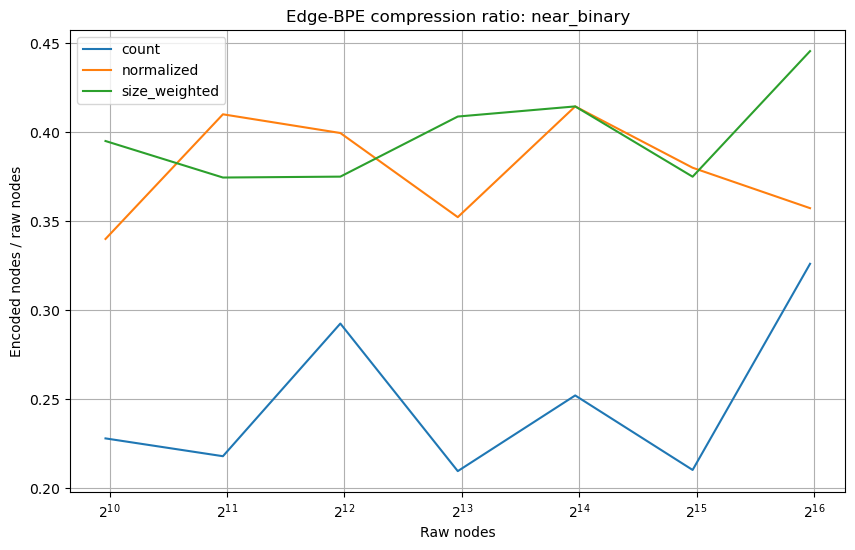

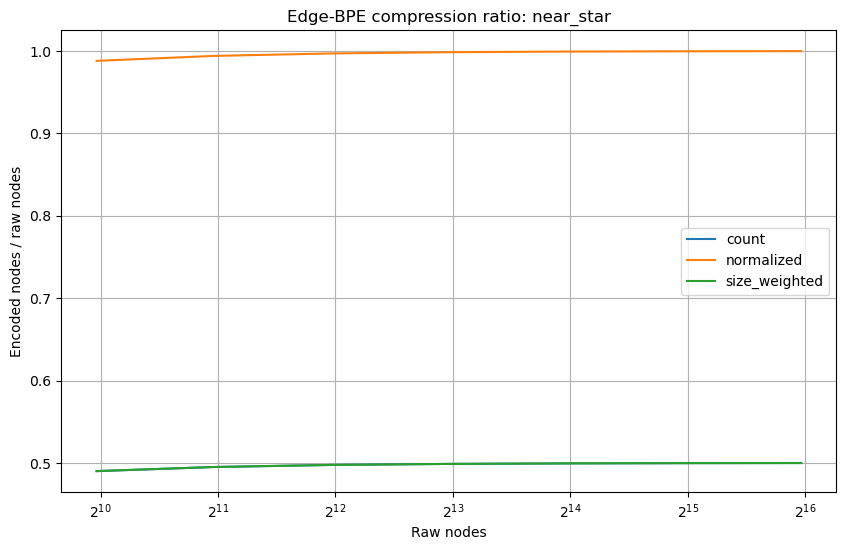

,shape,pair_score,rule_count,raw_pair_count_sum,actual_event_count_sum,encoded_nodes,compression_ratio
37,near_binary,count,12.0,74148.0,43133.0,20867.0,0.326047
39,near_binary,normalized,12.0,73147.0,41133.0,22867.0,0.357297
41,near_binary,size_weighted,12.0,68098.0,35489.0,28511.0,0.445484
79,near_star,count,12.0,191955.0,32010.0,31990.0,0.499844
81,near_star,normalized,12.0,191934.0,12.0,63988.0,0.999812
83,near_star,size_weighted,12.0,191955.0,32010.0,31990.0,0.499844


In [10]:
work_df = summary_df[summary_df["backend_requested"] == "python"].copy()

for shape in SHAPES:
    figure = plt.figure(figsize=(10, 6))
    axis = figure.gca()
    subset = work_df[work_df["shape"] == shape]
    for pair_score, group in subset.groupby("pair_score", sort=False):
        group = group.sort_values("n_nodes")
        axis.plot(
            group["n_nodes"],
            group["compression_ratio"],
            label=pair_score,
        )
    axis.set_xscale("log", base=2)
    axis.set_xlabel("Raw nodes")
    axis.set_ylabel("Encoded nodes / raw nodes")
    axis.set_title(f"Edge-BPE compression ratio: {shape}")
    axis.grid(True)
    axis.legend()
    plt.show()

largest_size = max(SIZES)
display(
    work_df[work_df["n_nodes"] == largest_size][
        [
            "shape",
            "pair_score",
            "rule_count",
            "raw_pair_count_sum",
            "actual_event_count_sum",
            "encoded_nodes",
            "compression_ratio",
        ]
    ].sort_values(["shape", "pair_score"])
)

## 10. Save reproducible results

Keep the raw rows, summary, and metadata together. Compare runs only when the
environment, validation level, warm-up policy, tree fixtures, merge budget, and
score settings agree.

In [11]:
if SAVE_RESULTS:
    output_dir = ROOT / "benchmark_results"
    output_dir.mkdir(exist_ok=True)
    raw_csv_path = output_dir / f"edge_bpe_timing_{PROFILE}.csv"
    summary_csv_path = output_dir / f"edge_bpe_timing_{PROFILE}_summary.csv"
    metadata_path = output_dir / f"edge_bpe_timing_{PROFILE}_metadata.json"

    results_df.to_csv(raw_csv_path, index=False)
    summary_df.to_csv(summary_csv_path, index=False)
    metadata = {
        "environment": ENVIRONMENT,
        "profile": PROFILE,
        "sizes": list(SIZES),
        "repeats": REPEATS,
        "shapes": list(SHAPES),
        "pair_scores": list(PAIR_SCORES),
        "backends": list(BACKENDS),
        "validate": VALIDATE,
        "num_merges": NUM_MERGES,
        "min_pair_count": MIN_PAIR_COUNT,
        "task_order_seed": TASK_ORDER_SEED,
        "numba_warmup": warmup_df.to_dict(orient="records"),
        "numba_cold_start_note": (
            "The first Numba fit is first-use in this notebook kernel, not a guaranteed "
            "clean-process cold-start measurement."
        ),
    }
    metadata_path.write_text(
        json.dumps(metadata, indent=2, sort_keys=True) + "\n",
        encoding="utf-8",
    )
    print(raw_csv_path.relative_to(ROOT))
    print(summary_csv_path.relative_to(ROOT))
    print(metadata_path.relative_to(ROOT))

benchmark_results/edge_bpe_timing_extended.csv
benchmark_results/edge_bpe_timing_extended_summary.csv
benchmark_results/edge_bpe_timing_extended_metadata.json


## 11. Release interpretation checklist

- All round-trip, nonmutation, history-parity, rule-parity, and encoded-parity
  checks must pass before interpreting timings.
- Compare warmed Numba fit rows with warmed rows; measure true cold-start latency
  in a fresh process.
- Inspect rule counts, actual contraction events, and compression alongside time.
  Scoring policies can legitimately perform different amounts of work.
- Treat transform/decode differences between backends as noise unless parity has
  failed—the backend does not implement those phases.
- Investigate sustained, repeatable slope changes or roughly 10–15%+ regressions,
  not one noisy point.
- Run representative CARBANAK/project trees before release. These controlled
  families are useful for diagnosis but are not workload substitutes.
- This notebook deliberately holds tree count at one. A separate corpus benchmark
  should vary tree count at fixed total vertices if many-tree fitting is important;
  changing both at once confounds interpretation.
- Peak memory and clean-process Numba startup remain separate release checks.